# Фреймворки Python для анализа данных

## Лабораторная работа №1.

### Выполнила: Китаева Дарья. М8О-102БВ-25

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)

In [ ]:
df = pd.read_csv("student_lifestyle_100k.csv", sep=",")
df.head()

Mounted at /content/drive/


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Прежде чем удалять некоторые стобцы проверим их корелляцию с другими столбцами, чтобы случайно не удалить что-то лишнее. Главные столбцы, связь с которыми мы проверяем - CGPA, Stress_Level и Depression.

# Корелляция с уровнем стресса

                    Student_ID       Age  Sleep_Duration  Study_Hours  \
Student_ID            1.000000  0.000855        0.002824     0.001945   
Age                   0.000855  1.000000        0.001357    -0.003808   
Sleep_Duration        0.002824  0.001357        1.000000     0.002744   
Study_Hours           0.001945 -0.003808        0.002744     1.000000   
Social_Media_Hours   -0.002281 -0.000436       -0.003008     0.005308   
Physical_Activity     0.003315 -0.003676        0.003166    -0.002045   
Stress_Level         -0.005230  0.002999       -0.281409     0.008731   

                    Social_Media_Hours  Physical_Activity  Stress_Level  
Student_ID                   -0.002281           0.003315     -0.005230  
Age                          -0.000436          -0.003676      0.002999  
Sleep_Duration               -0.003008           0.003166     -0.281409  
Study_Hours                   0.005308          -0.002045      0.008731  
Social_Media_Hours            1.000000       

<Axes: >

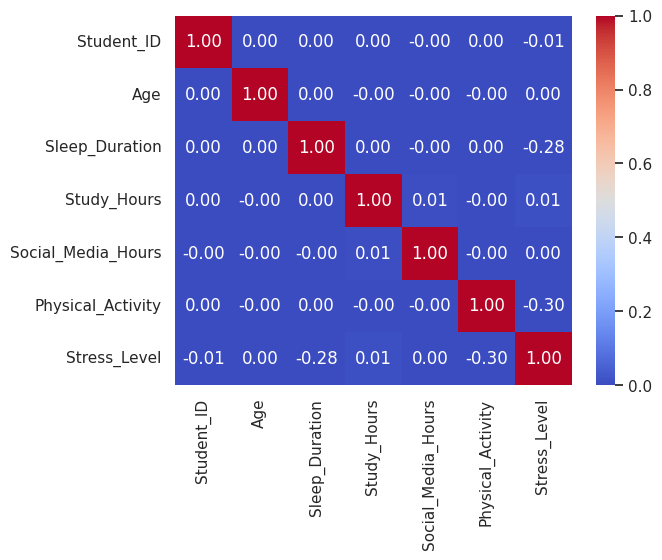

In [ ]:
numeric_columns = ['Student_ID', 'Age', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']
correlation_matrix = df[numeric_columns].corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt='.2f')

Можем заметить, что на уровень стресса не влияют такие показатели, как: ID студента, его возраст, время учёбы, время, проведённое в соцсетях. Сильно на уровень стресса влияют такие показатели, как: время сна и физическая активность. Чем меньше человек спал - тем больше его уровень стресса, также и с физической активностью: её меньше - стресс выше.

# Корелляция с CGPA

                    Student_ID       Age  Sleep_Duration  Study_Hours  \
Student_ID            1.000000  0.000855        0.002824     0.001945   
Age                   0.000855  1.000000        0.001357    -0.003808   
Sleep_Duration        0.002824  0.001357        1.000000     0.002744   
Study_Hours           0.001945 -0.003808        0.002744     1.000000   
Social_Media_Hours   -0.002281 -0.000436       -0.003008     0.005308   
Physical_Activity     0.003315 -0.003676        0.003166    -0.002045   
CGPA                 -0.001592  0.003248        0.015386     0.099534   

                    Social_Media_Hours  Physical_Activity      CGPA  
Student_ID                   -0.002281           0.003315 -0.001592  
Age                          -0.000436          -0.003676  0.003248  
Sleep_Duration               -0.003008           0.003166  0.015386  
Study_Hours                   0.005308          -0.002045  0.099534  
Social_Media_Hours            1.000000          -0.004788 -0.0879

<Axes: >

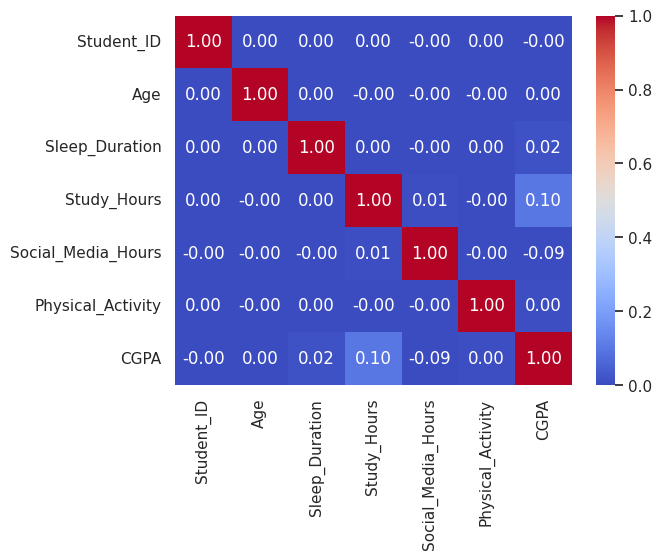

In [ ]:
numeric_columns = ['Student_ID', 'Age', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'CGPA']
correlation_matrix = df[numeric_columns].corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt='.2f')

Как мы можем видеть на оценку не влияют такие показатели, как: ID студента, его возраст, физическая активность. Наименьшее влияние имеют показатели: сон(если человек мало спал, его оценка будет ниже) и отрицательно влияют часы, проведённые в сосетях(чем больше человек провёл в них времени, тем ниже оценка). Наибольшее влияние имеет показатель часов, проведённых за учёбой: чем больше человек учился - тем выше его оценка.

# Корелляция с депрессией

                    Student_ID       Age  Sleep_Duration  Study_Hours  \
Student_ID            1.000000  0.000855        0.002824     0.001945   
Age                   0.000855  1.000000        0.001357    -0.003808   
Sleep_Duration        0.002824  0.001357        1.000000     0.002744   
Study_Hours           0.001945 -0.003808        0.002744     1.000000   
Social_Media_Hours   -0.002281 -0.000436       -0.003008     0.005308   
Physical_Activity     0.003315 -0.003676        0.003166    -0.002045   
Depression           -0.003663 -0.007722       -0.057529    -0.015932   

                    Social_Media_Hours  Physical_Activity  Depression  
Student_ID                   -0.002281           0.003315   -0.003663  
Age                          -0.000436          -0.003676   -0.007722  
Sleep_Duration               -0.003008           0.003166   -0.057529  
Study_Hours                   0.005308          -0.002045   -0.015932  
Social_Media_Hours            1.000000          -0.0047

<Axes: >

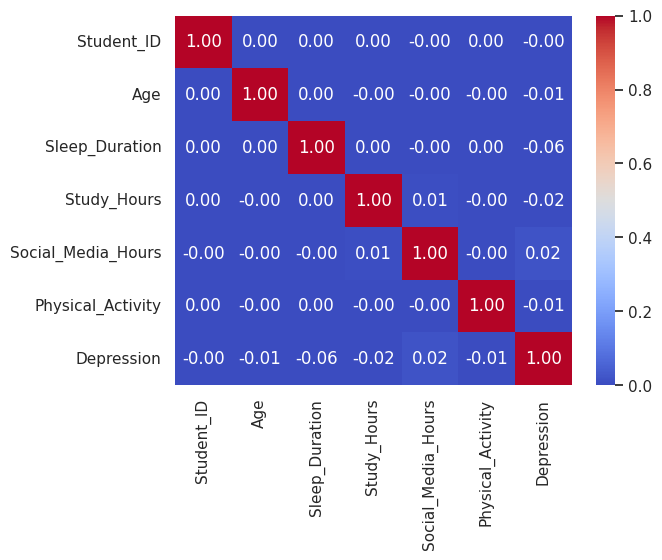

In [ ]:
numeric_columns = ['Student_ID', 'Age', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Depression']
correlation_matrix = df[numeric_columns].corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt='.2f')

Видим, что на уровень депресии больше всего влияют такие признаки: количество сна, количество часов, проведённых за учёбой, а также количество часов в соцсетях.

# Корелляция CGPA со строковыми признаками

In [ ]:
df.groupby('Gender')['CGPA'].mean()

,CGPA
Gender,
Female,2.901070
Male,2.895574


In [ ]:
df.groupby('Gender')['CGPA'].mean()

,CGPA
Gender,
Female,2.901070
Male,2.895574


Как мы видим средние оценки от факультета к факультету не особо меняются, также как у обоих полов средние оценки схожи.

# Корелляция уровня стресса со строковыми показателями

In [ ]:
df.groupby('Department')['Stress_Level'].mean()

,Stress_Level
Department,
Arts,4.128413
Business,4.133451
Engineering,4.126490
Medical,4.124274
Science,4.145633


In [ ]:
df.groupby('Gender')['Stress_Level'].mean()

,Stress_Level
Gender,
Female,4.130012
Male,4.133300


Также видим, что у каждого пола срдений уровень стресса схож, как и у различных факультетов.

# Корелляция депрессии со строковыми признаками

In [ ]:
df.groupby('Department')['Depression'].mean()

,Depression
Department,
Arts,0.101510
Business,0.101858
Engineering,0.100713
Medical,0.099529
Science,0.099497


In [ ]:
df.groupby('Gender')['Depression'].mean()

,Depression
Gender,
Female,0.099258
Male,0.101975


Аналогичная ситуация и с депрессией, как у обоих полов, так и у разных факультетов.

После того, как мы рассмотрели корелляцию всех признаков друг с другом мы можем сделать вывод о том, какие признаки не влияют на показатели, важные нам для анализа. Те признаки, которые мы можем удалить: ID студента, его возраст, факультет, на котором он учится, и его пол - данные признаки не только не несут информации, нужной нам, но и моугут помещать модели. Остальные признаки имеют влияние (из корелляции мы видим, что влияние не такое сильное, как хотелось бы, что тоже может влиять на обучение модели) на главные показатели, соответсвенно их мы оставляем.

# Удаляем строки, где у людей > 24 часов в сутках

In [7]:
print(df.shape)
df_indexes = df[(df['Sleep_Duration']+df['Study_Hours']+df['Social_Media_Hours']) > 24].index
df = df.drop(df_indexes, axis = 0)
print(df.shape)

(100000, 11)
(99921, 11)


# Удаление ненужных признаков и более удобные названия для столбцов

In [8]:
df.drop(columns=['Age', 'Gender', 'Department', 'Student_ID'], inplace=True)
df = df.rename(columns={"Sleep_Duration": "Sleep",
                        "Study_Hours": "Study",
                        "Social_Media_Hours": "Media",
                        "Physical_Activity": "Activity",
                        "Stress_Level": "Stress"
                        })
df.head()

,CGPA,Sleep,Study,Media,Activity,Stress,Depression
0,3.50,7.3,3.3,3.4,114,5,False
1,2.72,5.5,7.2,6.0,142,2,False
2,3.01,5.4,2.3,1.8,137,3,False
3,3.63,8.1,2.0,4.6,130,3,False
4,3.14,6.8,2.6,4.3,4,6,False


# Проверка на наличие дубликатов, пропусков и отсутствие данных

In [ ]:
print('До', df.shape)
duplicate_rows_df = df[df.duplicated()]
print("Число дублей: ", duplicate_rows_df.shape)
df = df.drop_duplicates()
print('После', df.shape)

До (99921, 7)
Число дублей:  (0, 7)
После (99921, 7)


In [ ]:
df.isnull().sum()

,0
CGPA,0
Sleep,0
Study,0
Media,0
Activity,0
Stress,0
Depression,0


Как мы можем видеть дубликатов в нашей таблице нет, также как и пропусков.

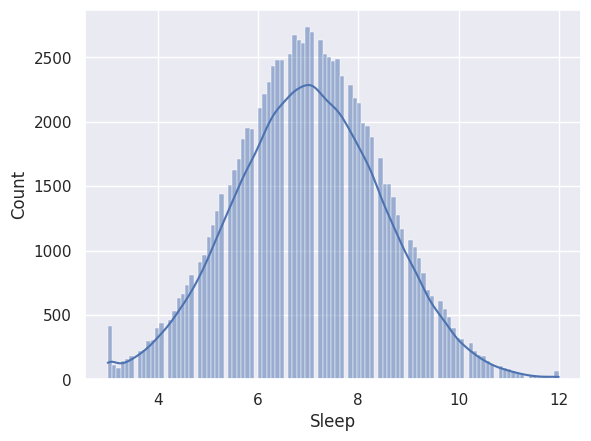

In [ ]:
sns.histplot(df['Sleep'], kde=True)
plt.show()

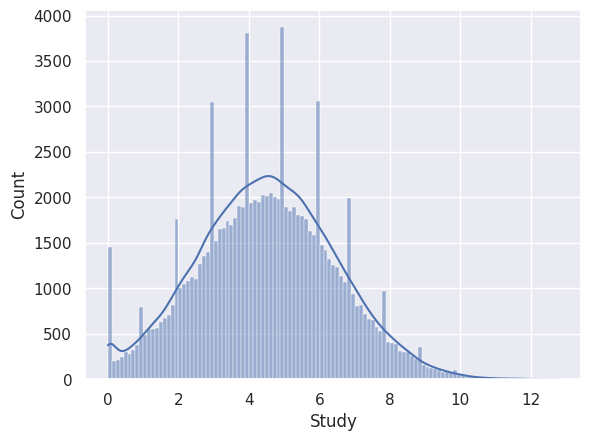

In [ ]:
sns.histplot(df['Study'], kde=True)
plt.show()

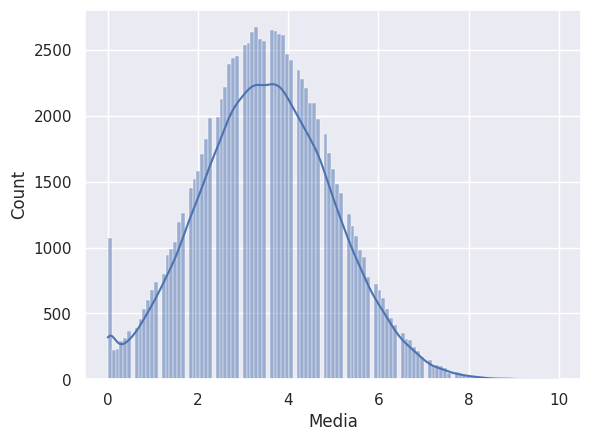

In [ ]:
sns.histplot(df['Media'], kde=True)
plt.show()

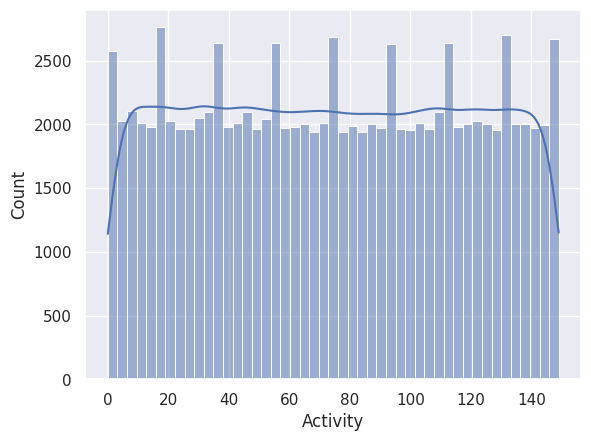

In [ ]:
sns.histplot(df['Activity'], kde=True)
plt.show()

Можем заметить, что на всех графиках в нуле происходит резкое возрастание, что может являться признаком того, что 0 = отсутствие данных, соответственно, нужно избавиться от этого.

# Найдём выбросы

<Axes: >

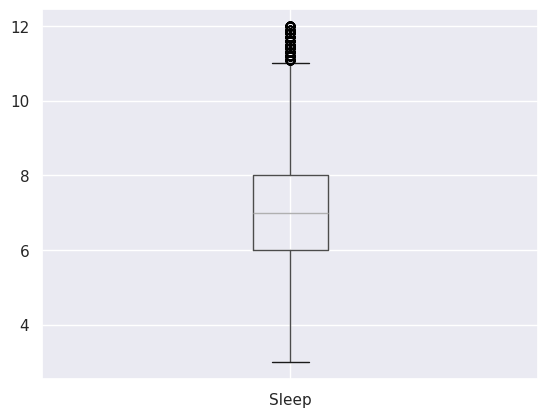

In [ ]:
df.boxplot(column=['Sleep'])

Заметим, что после 11 часов у нас идут точки - выбросы.

<Axes: >

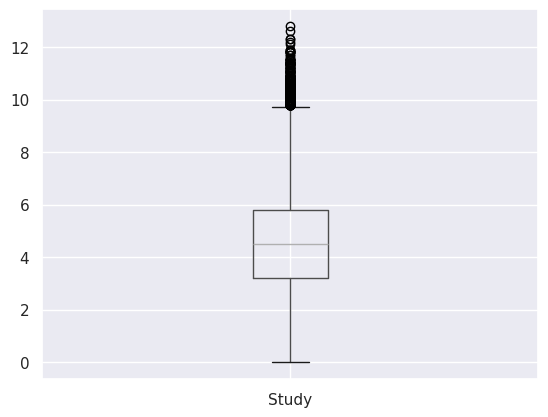

In [ ]:
df.boxplot(column=['Study'])

После 10 часов идут выбросы.

<Axes: >

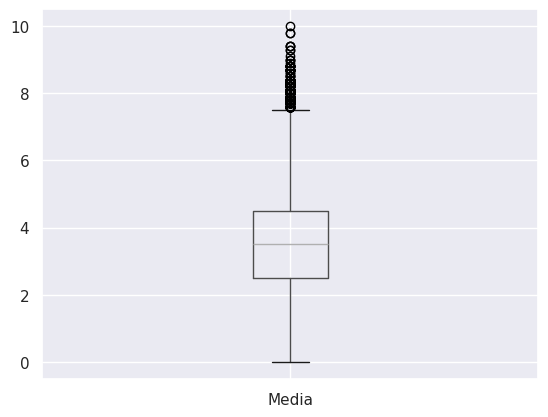

In [ ]:
df.boxplot(column=['Media'])

После 8 часов идут выбросы.

<Axes: >

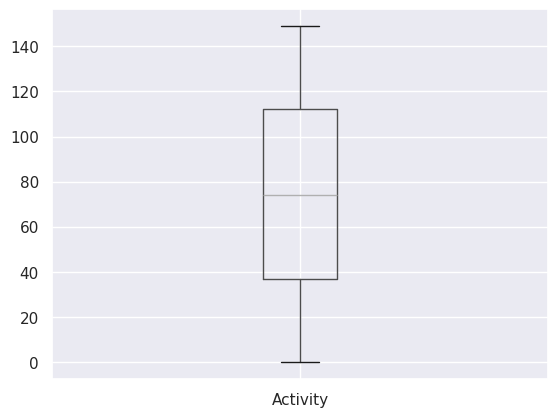

In [ ]:
df.boxplot(column=['Activity'])

Выбросов нет.

<Axes: >

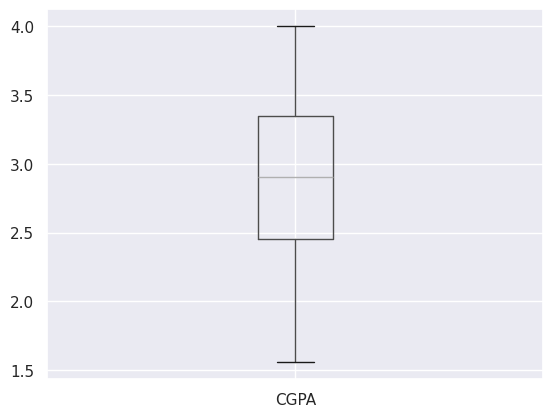

In [ ]:
df.boxplot(column=['CGPA'])

Выбросов нет.

<Axes: >

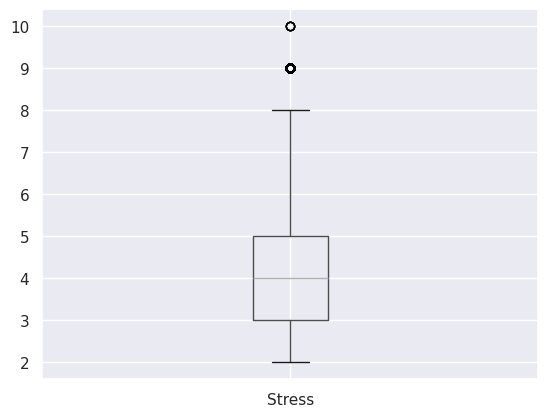

In [ ]:
df.boxplot(column=['Stress'])

Есть выбросы, находящиеся на 9 и 10.

<Axes: xlabel='Depression'>

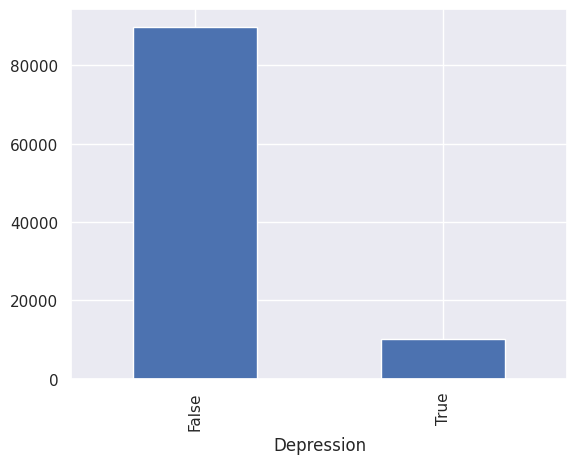

In [ ]:
df['Depression'].value_counts().plot.bar()

Выбросов в признаке "Депрессия" также нет (под выбросами подразумеваются значения, кроме "True" и "False"). Из графика мы можем видеть сильный дисбаланс: значений в столбце False намного больше, чем в столбце True.

# Проверка на дисбаланс

In [ ]:
print(df['Depression'].value_counts())

Depression
False    89864
True     10057
Name: count, dtype: int64


Можем заметить, что значений False в 9 раз больше, чем значений True, что может помешать модели в обучении, она может научиться говорить на всё "нет".

# Ограничение выбросов

Используем метод "capping" для того, чтобы не отбрасывать точки данных с экстремальными значениями, но они могут повлиять на наш анализ. Устанавливаем минимальное и максимальное значение, чтобы привести наши данные в диапазон от 5% до 95%, помещая их в этот диапазон.

In [9]:
def cap_outliers(df, lower=5, upper=95):
    lower_limit = np.percentile(df, lower)
    upper_limit = np.percentile(df, upper)
    return np.clip(df, lower_limit, upper_limit)

df['Sleep'] = cap_outliers(df['Sleep'])
df['Study'] = cap_outliers(df['Study'])
df['Media'] = cap_outliers(df['Media'])
df['CGPA'] = cap_outliers(df['CGPA'])

<Axes: >

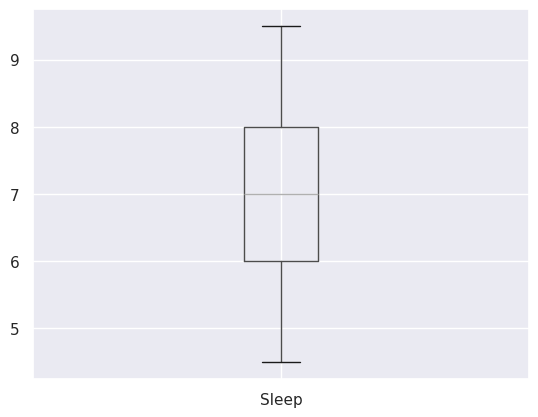

In [12]:
df.boxplot(column=['Sleep'])

<Axes: >

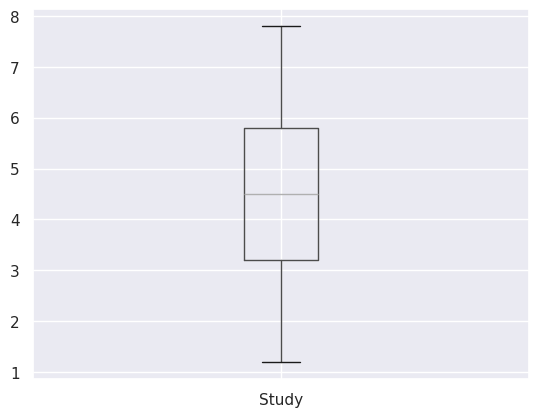

In [ ]:
df.boxplot(column=['Study'])

<Axes: >

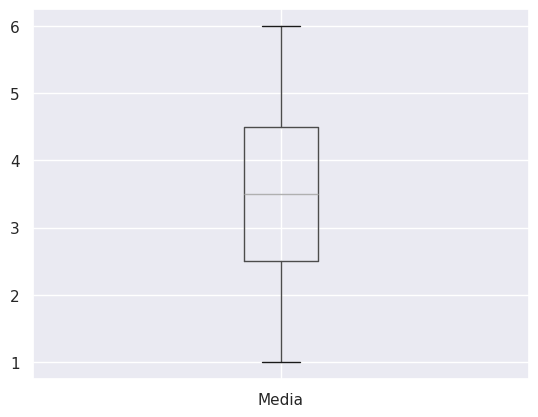

In [ ]:
df.boxplot(column=['Media'])

<Axes: >

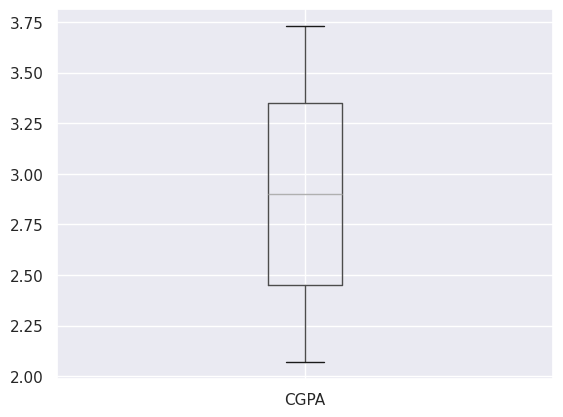

In [ ]:
df.boxplot(column=['CGPA'])

Выбросы убраны.

# Убираем отсутствие данных

In [10]:
df['Sleep'] = df['Sleep'].replace(0, df['Sleep'].median())
df['Study'] = df['Study'].replace(0, df['Study'].median())
df['Media'] = df['Media'].replace(0, df['Media'].median())
df['Activity'] = df['Activity'].replace(0, df['Activity'].median())

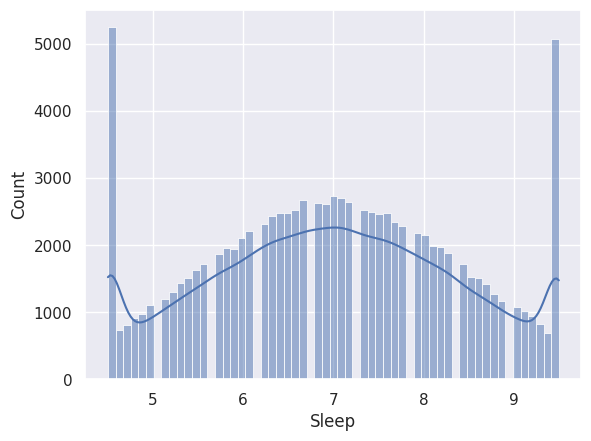

In [18]:
sns.histplot(df['Sleep'], kde=True)
plt.show()

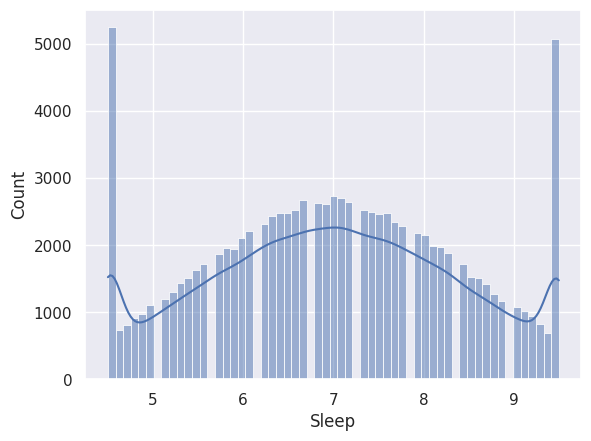

In [ ]:
sns.histplot(df['Sleep'], kde=True)
plt.show()

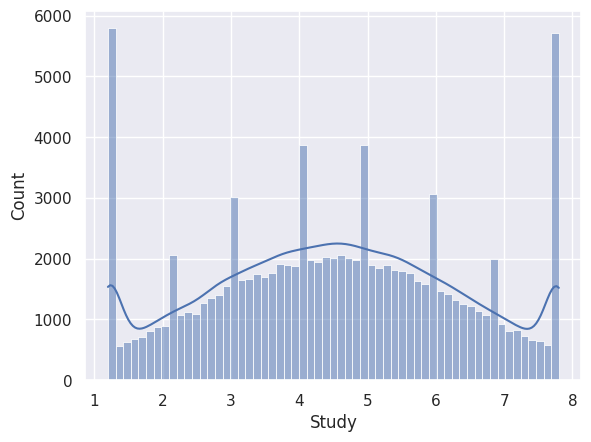

In [ ]:
sns.histplot(df['Study'], kde=True)
plt.show()

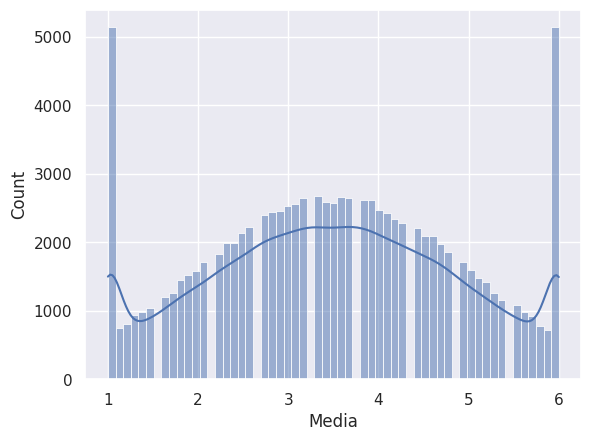

In [ ]:
sns.histplot(df['Media'], kde=True)
plt.show()

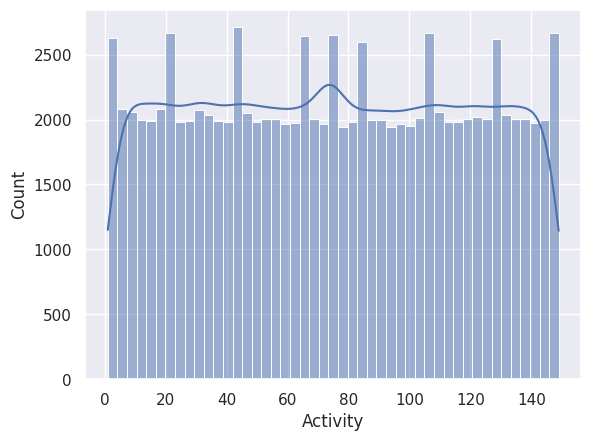

In [ ]:
sns.histplot(df['Activity'], kde=True)
plt.show()

# Кодирование категориальных признаков

Превращаем тектовые столбцы в числовые, тк модель не умеет работать со строками.

In [11]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression

le = LabelEncoder()

df['Depression'] = le.fit_transform(df['Depression'])

print(df[:8])

   CGPA  Sleep  Study  Media  Activity  Stress  Depression
0  3.50    7.3    3.3    3.4       114       5           0
1  2.72    5.5    7.2    6.0       142       2           0
2  3.01    5.4    2.3    1.8       137       3           0
3  3.63    8.1    2.0    4.6       130       3           0
4  3.14    6.8    2.6    4.3         4       6           0
5  3.31    6.5    3.5    4.1       129       2           0
6  2.14    4.5    4.0    3.1        73       8           1
7  3.27    7.0    3.4    6.0        68       4           0


# Избавляемся от дисбаланса классов

In [12]:
df_dp = df[df['Depression'] == 1]
df_no = df[df['Depression'] == 0]
df_no_dp = df_no.sample(n=10000, random_state=42)

print(df_dp[:5], "\n")
print(df_no_dp[:5])

    CGPA  Sleep  Study  Media  Activity  Stress  Depression
6   2.14    4.5    4.0    3.1        73       8           1
14  2.91    5.1    1.2    2.4        72       3           1
50  2.42    9.3    5.5    6.0       100       5           1
59  3.42    7.4    4.2    1.1         8       3           1
61  2.10    4.6    1.3    5.4       134       8           1 

       CGPA  Sleep  Study  Media  Activity  Stress  Depression
4503   2.32    5.1    2.0    3.3       101       2           0
55272  3.34    8.2    7.5    4.6        51       5           0
97119  3.04    7.1    6.2    3.0        23       3           0
65610  2.73    7.9    4.7    1.8        93       5           0
59237  2.69    8.4    4.7    4.8        54       5           0


Далее объединяем эти две табличцы и перемешиваем в них данные, чтобы модель не видела, что подряд идут только здоровые или только больные депрессией.

In [13]:
dfb = pd.concat([df_dp, df_no_dp], axis=0)
dfb = dfb.sample(frac=1, random_state=42).reset_index(drop=True)
print(dfb[:5])

   CGPA  Sleep  Study  Media  Activity  Stress  Depression
0  2.47    8.2    5.1    2.7        94       5           1
1  2.47    6.3    7.8    3.3        45       6           1
2  2.61    7.3    7.6    5.2        64       4           0
3  3.10    8.7    4.8    4.9        52       3           0
4  3.03    6.1    6.0    4.4       113       5           0


# Разделение данных на обучающую, валидационную и тестовую выборки без утечки данных

Удаляем столбец CGPA для линейной регресии, потому что для того, чтобы предсказать оценку, нам нужно учитывать есть ли депрессия у человека. Для обучения моделей для предсказания депресии соответсвенно удаляем уже оба столбца, чтобы модели не запутались.

In [39]:
from sklearn.model_selection import train_test_split

X_reg = df.drop(columns=['CGPA'])
y_reg = df['CGPA']

X_temp_reg, X_test_reg, y_temp_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(
    X_temp_reg, y_temp_reg, test_size=0.25, random_state=42
)

In [40]:
from sklearn.model_selection import train_test_split

X_clf = dfb.drop(columns=['CGPA', 'Depression'])
y_clf = dfb['Depression']

X_temp, X_test_clf, y_temp, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# Масштабирование

In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler_reg = MinMaxScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_val_reg_scaled = scaler_reg.transform(X_val_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

scaler_clf = MinMaxScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_val_clf_scaled = scaler_clf.transform(X_val_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# Обучение моделей

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [42]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import SGDClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model_reg = LinearRegression()
model_reg.fit(X_train_reg_scaled, y_train_reg)

model_clf = LogisticRegression(class_weight='balanced', C=0.1)
model_clf.fit(X_train_clf_scaled, y_train_clf)

model_sgd = SGDClassifier(loss='log_loss', max_iter=50, eta0=0.1, learning_rate='constant', class_weight='balanced', random_state=42)
model_sgd.fit(X_train_clf_scaled, y_train_clf)

model_catboost = CatBoostClassifier(iterations=30, learning_rate=0.05, depth=3, l2_leaf_reg=3, min_child_samples=50, class_weights={0:1, 1:9}, verbose=50, random_seed=42)
model_catboost.fit(X_train_clf_scaled, y_train_clf, eval_set=(X_val_clf_scaled, y_val_clf), early_stopping_rounds=20, verbose=50)

0:	learn: 0.6621066	test: 0.6620961	best: 0.6620961 (0)	total: 6.21ms	remaining: 180ms
29:	learn: 0.3521650	test: 0.3522981	best: 0.3522981 (29)	total: 97.2ms	remaining: 0us

bestTest = 0.3522980627
bestIteration = 29



CatBoostClassifier(class_weights={0: 1, 1: 9}, depth=3, iterations=30, l2_leaf_reg=3, learning_rate=0.05, min_child_samples=50, random_seed=42, verbose=50)

In [86]:
from math import sqrt
pred_reg = model_reg.predict(X_test_reg_scaled)
print(f"MAE: {mean_absolute_error(y_test_reg, pred_reg):.4f}")
print(f"MSE: {mean_squared_error(y_test_reg, pred_reg):.4f}")
print(f"RMSE: {sqrt(mean_squared_error(y_test_reg, pred_reg)):.4f}")
print(f"R² регрессии: {r2_score(y_test_reg, pred_reg):.4f}")

MAE: 0.4354
MSE: 0.2551
RMSE: 0.5051
R² регрессии: 0.0441


Расшифровка результатов:
*   MAE - средняя ошибка (на сколько баллов модель ошибается при предсказании оценки) = 0,44, т.е если у человека балл 4.5, то модель может предсказать, что у него 4.06 или же 4.94.
*   MSE - средняя квадратичная ошибка, не так интересна, как RMSE.
*   RMSE - корень из средней квадратичной ошибки, также как и MAE показывает среднюю ошибку, но сильнее штрафует модель за большие ошибки(если модель ошиблась не на 0.5, а на 2.0, то это считается большой ошибкой и разница между RMSE и MAE будет большая), разница между RMSE и MAE не сильно большая, примерно 0.7, что означает, что при предсказании ошибок модель не столкнулась с сильными  ошибками.
*   R² - объяснение моделью, почему у разных людей разные оценки = 0.044 - это значит, что в большинстве случаев модель предсказывает оценки не очень хорошо, фактически предсказывает среднее значение всех оценок из датасета.


**Вывод:** качество модели для предсказания CGPA крайне низкое. Модель объясняет лишь 4% изменчивости оценок у учеников, несмотря на то, что средняя ошибка не сильно высока. Низкое качество объясняется отсутствием сильной кореляции между признаками(сон, часы учёбы и соцсети) и CGPA. На основе имеющихся данных невозможно достоверно предсказать успеваемость студента. Для улучшения предсказаний модели требуются дополнительные признаки(желательно, чтобы их корелляция была выше, чем в данный момент).

In [80]:
prob_clf = model_clf.predict_proba(X_test_clf_scaled)[:, 1]
pred_clf = (prob_clf > 0.5).astype(int)

recall = recall_score(y_test_clf, pred_clf)
precision = precision_score(y_test_clf, pred_clf)

print(f"Precision логистической: {precision_score(y_test_clf, pred_clf):.4f}")
print(f"Recall логистической: {recall_score(y_test_clf, pred_clf):.4f}")
print(f"F1 логистической: {f1_score(y_test_clf, pred_clf):.4f}")
print(confusion_matrix(y_test_clf, pred_clf))

Precision логистической: 0.5468
Recall логистической: 0.4995
F1 логистической: 0.5221
[[1167  833]
 [1007 1005]]


Расшифрока результатов:
*   Precision - процент того, насколько модель верна в предсказаниях. Если модель говорит, что у человека депрессия, то с шансом 54% это окажется правдой.
*   Recall - ппроцент того, сколько человек с депрессией нашла модель(из всех болеющих депрессией). Модель находит почти 50% человек с депрессией.
*   F1 - среднее гармоническое между Precision и Recall -  отражает общее качество модели. Равен 52%, соответственно, можно утверждать, что модель не самая лучшая, но и не безнадёжная.
*   Матрица: TN = 1167 - модель верно определила студентов без депрессии; FP = 833 - модель занесла здоровых людей в больных депрессией; FN = 1007 - пропущенные люди, действительно болеющие депрессией; TP = 1005 - правильно предсказанная депрессия.


**Вывод:** модель недостаточно точна. Однако она демонстрирует хороший результат и лучший из 3х проверенных моделей (спойлер).

In [81]:
prob_clf_sgd = model_sgd.predict_proba(X_test_clf_scaled)[:, 1]
pred_clf_sgd = (prob_clf_sgd > 0.5).astype(int)

recall_sgd = recall_score(y_test_clf, pred_clf_sgd)
precision_sgd = precision_score(y_test_clf, pred_clf_sgd)

print(f"Precision SGD: {precision_score(y_test_clf, pred_clf_sgd):.4f}")
print(f"Recall SGD: {recall_score(y_test_clf, pred_clf_sgd):.4f}")
print(f"F1 SGD: {f1_score(y_test_clf, pred_clf_sgd):.4f}")
print(confusion_matrix(y_test_clf, pred_clf_sgd))

Precision SGD: 0.7893
Recall SGD: 0.1322
F1 SGD: 0.2265
[[1929   71]
 [1746  266]]


Расшифрока результатов:
*   Precision - процент того, насколько модель верна в предсказаниях. Если модель говорит, что у человека депрессия, то с шансом 78% это окажется правдой.
*   Recall - ппроцент того, сколько человек с депрессией нашла модель(из всех болеющих депрессией). Модель находит всего 13% человек с депрессией.
*   F1 - среднее гармоническое между Precision и Recall -  отражает общее качество модели. Равен 22%, соответственно, можно утверждать, что модель плохо определяет людей, у которых действительно есть депрессия, на большинство она говорит, что есть.
*   Матрица: TN = 1929 - модель верно определила студентов без депрессии; FP = 71 - модель занесла здоровых людей в больных депрессией; FN = 1746 - пропущенные люди, действительно болеющие депрессией; TP = 266 - правильно предсказанная депрессия.

**Вывод:** модель плоха. Она плохо предсказывает депрессию у человека, несмотря на то, что практически всех людей без депрессии она угадала правильно. Скорее всего модель склонна к тому, чтобы на всё говорить "да".

In [82]:
prob_clf_cat = model_catboost.predict_proba(X_test_clf_scaled)[:, 1]
pred_clf_cat = (prob_clf_cat > 0.5).astype(int)

recall_cat = recall_score(y_test_clf, pred_clf_cat)
precision_cat = precision_score(y_test_clf, pred_clf_cat)

print(f"Precision CatBoost: {precision_score(y_test_clf, pred_clf_cat):.4f}")
print(f"Recall CatBoost: {recall_score(y_test_clf, pred_clf_cat):.4f}")
print(f"F1 CatBoost: {f1_score(y_test_clf, pred_clf_cat):.4f}")
print(confusion_matrix(y_test_clf, pred_clf_cat))

Precision CatBoost: 0.6031
Recall CatBoost: 0.3315
F1 CatBoost: 0.4278
[[1561  439]
 [1345  667]]


Расшифрока результатов:
*   Precision - процент того, насколько модель верна в предсказаниях. Если модель говорит, что у человека депрессия, то с шансом 60% это окажется правдой.
*   Recall - ппроцент того, сколько человек с депрессией нашла модель(из всех болеющих депрессией). Модель находит 33% человек с депрессией.
*   F1 - среднее гармоническое между Precision и Recall -  отражает общее качество модели. Равен 43%, соответственно, можно утверждать, что модель довольно неплохо предсказывает людей без депрессии, но к сожалению это меньше, чем 50%.
*   Матрица: TN = 1561 - модель верно определила студентов без депрессии; FP = 439 - модель занесла здоровых людей в больных депрессией; FN = 1345 - пропущенные люди, действительно болеющие депрессией; TP = 667 - правильно предсказанная депрессия.

**Вывод:** данная модель - что-то среднее между двумя предыдущими. Довольно хорошо находит людей без депрессии, но людей с депрессией в большинстве случаев пропускает.

In [85]:
probabilities_val = model_clf.predict_proba(X_val_clf_scaled)[:, 1]
predictions_val = (probabilities_val > 0.5).astype(int)

probabilities_valsgd = model_sgd.predict_proba(X_val_clf_scaled)[:, 1]
predictions_valsgd = (probabilities_valsgd > 0.5).astype(int)

probabilities_valcat = model_catboost.predict_proba(X_val_clf_scaled)[:, 1]
predictions_valcat = (probabilities_valcat > 0.5).astype(int)

print("LogisticRegression")
print(f'Валидация: Recall: {recall_score(y_val_clf, predictions_val):.4f}')
print(f'Тест: Recall: {recall:.4f}')
print(f'Валидация: Precision: {precision_score(y_val_clf, predictions_val):.4f}')
print(f'Тест: Precisiont: {precision:.4f}', "\n")

print("SGDClassifier")
print(f'Валидация: Recall: {recall_score(y_val_clf, predictions_valsgd):.4f}')
print(f'Тест: Recall: {recall_sgd:.4f}')
print(f'Валидация: Precision: {precision_score(y_val_clf, predictions_valsgd):.4f}')
print(f'Тест: Precisiont: {precision_sgd:.4f}', "\n")

print("CatBoost")
print(f'Валидация: Recall: {recall_score(y_val_clf, predictions_valcat):.4f}')
print(f'Тест: Recall: {recall_cat:.4f}')
print(f'Валидация: Precision: {precision_score(y_val_clf, predictions_valcat):.4f}')
print(f'Тест: Precisiont: {precision_cat:.4f}', "\n")

LogisticRegression
Валидация: Recall: 0.4816
Тест: Recall: 0.4995
Валидация: Precision: 0.5410
Тест: Precisiont: 0.5468 

SGDClassifier
Валидация: Recall: 0.1272
Тест: Recall: 0.1322
Валидация: Precision: 0.7232
Тест: Precisiont: 0.7893 

CatBoost
Валидация: Recall: 0.3226
Тест: Recall: 0.3315
Валидация: Precision: 0.5879
Тест: Precisiont: 0.6031 



Ни у одной модели результат на тестовой выборке не превыщает результат на валидационной выборке более, чем на 2% (2% или 0.1 - показатель переобучения модели), соотвественно, делаем вывод, что модели не переобучаются.

# Обучение модели на несбалансированных данных

На несбалансированных данных проверяем только модели, предсказывающие депрессию, так как модель, предсказывающая оценки не нуждается в балансировке данных, где мы взяли 10% false от всех не болеющих депрессией.

In [47]:
from sklearn.model_selection import train_test_split

X_clf_two = df.drop(columns=['CGPA', 'Depression'])
y_clf_two = df['Depression']

X_temp_two, X_test_two, y_temp_two, y_test_two = train_test_split(
    X_clf_two, y_clf_two, test_size=0.2, random_state=42, stratify=y_clf_two
)

X_train_two, X_val_two, y_train_two, y_val_two = train_test_split(
    X_temp_two, y_temp_two, test_size=0.25, random_state=42, stratify=y_temp_two
)

In [48]:
from sklearn.preprocessing import MinMaxScaler

scaler_two = MinMaxScaler()
X_train_two_scaled = scaler_two.fit_transform(X_train_two)
X_val_two_scaled = scaler_two.transform(X_val_two)
X_test_two_scaled = scaler_two.transform(X_test_two)

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

model_clf_two = LogisticRegression(class_weight='balanced', C=0.1)
model_clf_two.fit(X_train_two_scaled, y_train_two)

model_sgd_two = SGDClassifier(loss='log_loss', max_iter=50, eta0=0.1, learning_rate='constant', class_weight='balanced', random_state=42)
model_sgd_two.fit(X_train_two_scaled, y_train_two)

model_catboost_two = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, class_weights={0:1, 1:9}, verbose=50, random_seed=42)
model_catboost_two.fit(X_train_two_scaled, y_train_two, eval_set=(X_val_two_scaled, y_val_two), early_stopping_rounds=20, verbose=50)

0:	learn: 0.6902296	test: 0.6905403	best: 0.6905403 (0)	total: 42.1ms	remaining: 4.17s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.6771379472
bestIteration = 26

Shrink model to first 27 iterations.


CatBoostClassifier(class_weights={0: 1, 1: 9}, depth=6, iterations=100, learning_rate=0.1, random_seed=42, verbose=50)

In [60]:
prob_two = model_clf_two.predict_proba(X_test_two_scaled)[:, 1]
pred_two = (prob_two > 0.5).astype(int)
print(f"Precision логистической: {precision_score(y_test_two, pred_two):.4f}")
print(f"Recall логистической: {recall_score(y_test_two, pred_two):.4f}")
print(f"F1 логистической: {f1_score(y_test_two, pred_two):.4f}")
print(confusion_matrix(y_test_two, pred_two))

Precision логистической: 0.1166
Recall логистической: 0.4888
F1 логистической: 0.1882
[[10524  7450]
 [ 1028   983]]


**Вывод:** модель стала предскзывать намного хуже. Precision: 54% -> 11%; Recall: 50% - 48%; F1: 52% - 18%. Из этого можем сделать вывод, что модель перестала понимать закономерность, где у людей может быть депрессия и где не может быть и стала практически на всё говорить, что депрессия есть (очень сильно на неё влияет дисбаланс, где false у 90%, а true - у 10%).

In [61]:
prob_two_sgd = model_sgd_two.predict_proba(X_test_two_scaled)[:, 1]
pred_two_sgd = (prob_two_sgd > 0.5).astype(int)
print(f"Precision SGD: {precision_score(y_test_two, pred_two_sgd):.4f}")
print(f"Recall SGD: {recall_score(y_test_two, pred_two_sgd):.4f}")
print(f"F1 SGD: {f1_score(y_test_two, pred_two_sgd):.4f}")
print(confusion_matrix(y_test_two, pred_two_sgd))

Precision SGD: 0.2090
Recall SGD: 0.1154
F1 SGD: 0.1487
[[17096   878]
 [ 1779   232]]


**Вывод:** модель также стала предскзывать намного хуже. Precision: 78% -> 20%; Recall: 13% - 11%; F1: 22% - 14%. Раньше модель в целом очень хорошо предскзывала людей, у которых есть депрессия, сейчас же модель, видимо, запуталась и перестала даже предсказывать, что у людей, у которых действительно нет депрессии, - её нет.

In [62]:
prob_two_cat = model_catboost_two.predict_proba(X_test_two_scaled)[:, 1]
pred_two_cat = (prob_two_cat > 0.5).astype(int)
print(f"Precision CatBoost: {precision_score(y_test_two, pred_two_cat):.4f}")
print(f"Recall CatBoost: {recall_score(y_test_two, pred_two_cat):.4f}")
print(f"F1 CatBoost: {f1_score(y_test_two, pred_two_cat):.4f}")
print(confusion_matrix(y_test_two, pred_two_cat))

Precision CatBoost: 0.1368
Recall CatBoost: 0.3088
F1 CatBoost: 0.1896
[[14057  3917]
 [ 1390   621]]


**Вывод:** на данную модель также очень сильно повлиял дисбаланс классов. Precision: 60% -> 13%; Recall: 33% - 30%; F1: 42% - 18%. Стала плохо предсказывать людей, у которых нет депрессии, хотя примерно также предсказывает людей, у которых есть депрессия.

# Обучение моделей без удаления признаков: факультет, возраст, ...

In [ ]:
df_new = pd.read_csv("student_lifestyle_100k.csv", sep=",")
df_new.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [55]:
df_new = df_new.rename(columns={"Sleep_Duration": "Sleep",
                        "Study_Hours": "Study",
                        "Social_Media_Hours": "Media",
                        "Physical_Activity": "Activity",
                        "Stress_Level": "Stress"
                        })

In [56]:
print(df_new.shape)
df_indexes = df_new[(df_new['Sleep']+df_new['Study']+df_new['Media']) > 24].index
df_new = df_new.drop(df_indexes, axis = 0)
print(df_new.shape)

(100000, 11)
(99921, 11)


In [57]:
def cap_outliers(df, lower=5, upper=95):
    lower_limit = np.percentile(df, lower)
    upper_limit = np.percentile(df, upper)
    return np.clip(df, lower_limit, upper_limit)

df_new['Sleep'] = cap_outliers(df_new['Sleep'])
df_new['Study'] = cap_outliers(df_new['Study'])
df_new['Media'] = cap_outliers(df_new['Media'])
df_new['CGPA'] = cap_outliers(df_new['CGPA'])

In [58]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression

df_new = df_new.copy()
le = LabelEncoder()

df_new['Depression'] = le.fit_transform(df_new['Depression'])
df_new['Gender'] = le.fit_transform(df_new['Gender'])
df_new['Department'] = le.fit_transform(df_new['Department'])

print(df_new[:10])

   Student_ID  Age  Gender  Department  CGPA  Sleep  Study  Media  Activity  \
0        1001   22       0           4  3.50    7.3    3.3    3.4       114   
1        1002   20       1           2  2.72    5.5    7.2    6.0       142   
2        1003   20       1           3  3.01    5.4    2.3    1.8       137   
3        1004   21       1           2  3.63    8.1    2.0    4.6       130   
4        1005   19       1           0  3.14    6.8    2.6    4.3         4   
5        1006   22       0           3  3.31    6.5    3.5    4.1       129   
6        1007   18       1           4  2.14    4.5    4.0    3.1        73   
7        1008   18       1           2  3.27    7.0    3.4    6.0        68   
8        1009   21       1           1  2.71    4.8    7.8    1.0        82   
9        1010   24       1           2  3.36    5.7    1.5    3.7        59   

   Stress  Depression  
0       5           0  
1       2           0  
2       3           0  
3       3           0  
4       6 

In [63]:
df_new_dp = df_new[df_new['Depression'] == 1]
df_new_no = df_new[df_new['Depression'] == 0]
df_new_no_dp = df_new_no.sample(n=10000, random_state=42)

print(df_new_dp[:5], "\n")
print(df_new_no_dp[:5])

    Student_ID  Age  Gender  Department  CGPA  Sleep  Study  Media  Activity  \
6         1007   18       1           4  2.14    4.5    4.0    3.1        73   
14        1015   22       0           0  2.91    5.1    1.2    2.4        72   
50        1051   19       0           4  2.42    9.3    5.5    6.0       100   
59        1060   20       0           2  3.42    7.4    4.2    1.1         8   
61        1062   22       0           1  2.10    4.6    1.3    5.4       134   

    Stress  Depression  
6        8           1  
14       3           1  
50       5           1  
59       3           1  
61       8           1   

       Student_ID  Age  Gender  Department  CGPA  Sleep  Study  Media  \
4503         5504   21       0           3  2.32    5.1    2.0    3.3   
55272       56273   21       0           1  3.34    8.2    7.5    4.6   
97119       98120   24       1           2  3.04    7.1    6.2    3.0   
65610       66611   24       1           1  2.73    7.9    4.7    1.8   
59

In [64]:
df_newb = pd.concat([df_new_dp, df_new_no_dp], axis=0)
df_newb = df_newb.sample(frac=1, random_state=42).reset_index(drop=True)
print(df_newb[:5])

   Student_ID  Age  Gender  Department  CGPA  Sleep  Study  Media  Activity  \
0       82261   24       0           1  2.47    8.2    5.1    2.7        94   
1       42775   24       0           3  2.47    6.3    7.8    3.3        45   
2       90085   23       1           4  2.61    7.3    7.6    5.2        64   
3       80476   22       0           4  3.10    8.7    4.8    4.9        52   
4       24096   19       0           2  3.03    6.1    6.0    4.4       113   

   Stress  Depression  
0       5           1  
1       6           1  
2       4           0  
3       3           0  
4       5           0  


In [65]:
from sklearn.model_selection import train_test_split

X_reg_two = df_new.drop(columns=['CGPA'])
y_reg_two = df_new['CGPA']

X_temp_reg_two, X_test_reg_two, y_temp_reg_two, y_test_reg_two = train_test_split(
    X_reg_two, y_reg_two, test_size=0.2, random_state=42
)
X_train_reg_two, X_val_reg_two, y_train_reg_two, y_val_reg_two = train_test_split(
    X_temp_reg_two, y_temp_reg_two, test_size=0.25, random_state=42
)

In [66]:
scaler_reg_two = MinMaxScaler()
X_train_reg_two_scaled = scaler_reg_two.fit_transform(X_train_reg_two)
X_val_reg_two_scaled = scaler_reg_two.transform(X_val_reg_two)
X_test_reg_two_scaled = scaler_reg_two.transform(X_test_reg_two)

In [67]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_reg_two = LinearRegression()
model_reg_two.fit(X_train_reg_two_scaled, y_train_reg_two)

LinearRegression()

In [68]:
pred_reg_two = model_reg_two.predict(X_test_reg_two_scaled)
print(f"MAE: {mean_absolute_error(y_test_reg_two, pred_reg_two):.4f}")
print(f"MSE: {mean_squared_error(y_test_reg_two, pred_reg_two):.4f}")
print(f"R² регрессии: {r2_score(y_test_reg_two, pred_reg_two):.4f}")

MAE: 0.4354
MSE: 0.2551
R² регрессии: 0.0440


**Вывод:** модель предсказывает оценки точно также, как и в прошлый раз (изменился толко R²: 0.0441 -> 0.0440). Значит, модели не так важно есть ли признаки: факультет, возраст и тд, или нет. На неё эти признаки не влияют сильно (можно сказать вообще не влияют).

In [69]:
from sklearn.model_selection import train_test_split

X_clf_three = df_newb.drop(columns=['CGPA', 'Depression'])
y_clf_three = df_newb['Depression']

X_temp_three, X_test_three, y_temp_three, y_test_three = train_test_split(
    X_clf_three, y_clf_three, test_size=0.2, random_state=42, stratify=y_clf_three
)

X_train_three, X_val_three, y_train_three, y_val_three = train_test_split(
    X_temp_three, y_temp_three, test_size=0.25, random_state=42, stratify=y_temp_three
)

In [70]:
from sklearn.preprocessing import MinMaxScaler

scaler_three = MinMaxScaler()
X_train_three_scaled = scaler_three.fit_transform(X_train_three)
X_val_three_scaled = scaler_three.transform(X_val_three)
X_test_three_scaled = scaler_three.transform(X_test_three)

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

model_clf_three = LogisticRegression(class_weight='balanced', C=0.1)
model_clf_three.fit(X_train_three_scaled, y_train_three)

model_sgd_three = SGDClassifier(loss='log_loss', max_iter=50, eta0=0.1, learning_rate='constant', class_weight='balanced', random_state=42)
model_sgd_three.fit(X_train_three_scaled, y_train_three)

model_catboost_three = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, class_weights={0:1, 1:9}, verbose=50, random_seed=42)
model_catboost_three.fit(X_train_three_scaled, y_train_three, eval_set=(X_val_three_scaled, y_val_three), early_stopping_rounds=20, verbose=50)

0:	learn: 0.6323852	test: 0.6324481	best: 0.6324481 (0)	total: 6.75ms	remaining: 669ms
50:	learn: 0.3170845	test: 0.3202533	best: 0.3202500 (49)	total: 422ms	remaining: 405ms
99:	learn: 0.3126957	test: 0.3198742	best: 0.3198025 (84)	total: 829ms	remaining: 0us

bestTest = 0.3198025011
bestIteration = 84

Shrink model to first 85 iterations.


CatBoostClassifier(class_weights={0: 1, 1: 9}, depth=6, iterations=100, learning_rate=0.1, random_seed=42, verbose=50)

In [72]:
prob_three = model_clf_three.predict_proba(X_test_three_scaled)[:, 1]
pred_three = (prob_three > 0.5).astype(int)
print(f"Precision логистической: {precision_score(y_test_three, pred_three):.4f}")
print(f"Recall логистической: {recall_score(y_test_three, pred_three):.4f}")
print(f"F1 логистической: {f1_score(y_test_three, pred_three):.4f}")
print(confusion_matrix(y_test_three, pred_three))

Precision логистической: 0.5524
Recall логистической: 0.5000
F1 логистической: 0.5249
[[1185  815]
 [1006 1006]]


**Вывод:** модель стала предсказывать чуть лучше. Precision: 54% -> 55%; Recall: 49% - 50%; F1: 52.2% - 52.5%. Соответсвенно делаем вывод, что для модели не так важно есть ли эти признаки или нет, хотя ей конечно лучше, если данные прихнаки есть.

In [73]:
prob_three_sgd = model_sgd_three.predict_proba(X_test_three_scaled)[:, 1]
pred_three_sgd = (prob_three_sgd > 0.5).astype(int)
print(f"Precision SGD: {precision_score(y_test_three, pred_three_sgd):.4f}")
print(f"Recall SGD: {recall_score(y_test_three, pred_three_sgd):.4f}")
print(f"F1 SGD: {f1_score(y_test_three, pred_three_sgd):.4f}")
print(confusion_matrix(y_test_three, pred_three_sgd))

Precision SGD: 0.5248
Recall SGD: 0.7575
F1 SGD: 0.6200
[[ 620 1380]
 [ 488 1524]]


**Вывод:** модель также стала предскзывать намного лучше, чем было. Precision: 78% -> 52%; Recall: 13% - 75%; F1: 22% - 62%. Несмотря на то, что модель стала чуть хуже предсказывать людей, у которых нет депрессии, она стала намного лучше предсказывать людей, у которых она есть. Значит делаем вывод, что для этой модели очень желательно иметь все признаки для хороших предсказаний.

In [74]:
prob_three_cat = model_catboost_three.predict_proba(X_test_three_scaled)[:, 1]
pred_three_cat = (prob_three_cat > 0.5).astype(int)
print(f"Precision CatBoost: {precision_score(y_test_three, pred_three_cat):.4f}")
print(f"Recall CatBoost: {recall_score(y_test_three, pred_three_cat):.4f}")
print(f"F1 CatBoost: {f1_score(y_test_three, pred_three_cat):.4f}")
print(confusion_matrix(y_test_three, pred_three_cat))

Precision CatBoost: 0.5015
Recall CatBoost: 1.0000
F1 CatBoost: 0.6680
[[   0 2000]
 [   0 2012]]


**Вывод:** модель переобучилась, так как стала на абсолютно всех людей говорить, что у них депрессия. Она, конечно, угадала, что у людей есть депрессия, но также на тех, у кого её нет - она сказала, что у них есть депрессия. Значит можем сделать вывод, что модель плохо работает с таким количеством признаков.

# Обучение моделей без удаления выбросов

In [ ]:
from sklearn.preprocessing import LabelEncoder
df_wo = pd.read_csv("student_lifestyle_100k.csv", sep=",")
df_wo.drop(columns=['Age', 'Gender', 'Department', 'Student_ID'], inplace=True)
df_wo = df_wo.rename(columns={"Sleep_Duration": "Sleep",
                        "Study_Hours": "Study",
                        "Social_Media_Hours": "Media",
                        "Physical_Activity": "Activity",
                        "Stress_Level": "Stress"
                        })
df_wo_indexes = df_wo[(df_wo['Sleep']+df_wo['Study']+df_wo['Media']) > 24].index
df_wo = df_wo.drop(df_wo_indexes, axis = 0)
df_wo = df_wo.copy()
le = LabelEncoder()
df_wo['Depression'] = le.fit_transform(df_wo['Depression'])

df_wo_dp = df_wo[df_wo['Depression'] == 1]
df_wo_no = df_wo[df_wo['Depression'] == 0]
df_wo_no_dp = df_wo_no.sample(n=10000, random_state=42)

df_wob = pd.concat([df_wo_dp, df_wo_no_dp], axis=0)
df_wob = df_wob.sample(frac=1, random_state=42).reset_index(drop=True)

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_reg_wo = df_wo.drop(columns=['CGPA'])
y_reg_wo = df_wo['CGPA']

X_temp_reg_wo, X_test_reg_wo, y_temp_reg_wo, y_test_reg_wo = train_test_split(
    X_reg_wo, y_reg_wo, test_size=0.2, random_state=42
)
X_train_reg_wo, X_val_reg_wo, y_train_reg_wo, y_val_reg_wo = train_test_split(
    X_temp_reg_wo, y_temp_reg_wo, test_size=0.25, random_state=42
)

scaler_reg_wo = MinMaxScaler()
X_train_reg_wo_scaled = scaler_reg_wo.fit_transform(X_train_reg_wo)
X_val_reg_wo_scaled = scaler_reg_wo.transform(X_val_reg_wo)
X_test_reg_wo_scaled = scaler_reg_wo.transform(X_test_reg_wo)

model_reg_wo = LinearRegression()
model_reg_wo.fit(X_train_reg_wo_scaled, y_train_reg_wo)

pred_reg_wo = model_reg_wo.predict(X_test_reg_wo_scaled)
print(f"MAE: {mean_absolute_error(y_test_reg_wo, pred_reg_wo):.4f}")
print(f"MSE: {mean_squared_error(y_test_reg_wo, pred_reg_wo):.4f}")
print(f"R² регрессии: {r2_score(y_test_reg_wo, pred_reg_wo):.4f}")

MAE: 0.4432
MSE: 0.2682
R² регрессии: 0.0470


**Вывод:** модель стала работать чуть лучше, если не удалять выбросы (где у некоторых людей может быть время сна в районе 12 часов). MAE и MSE стали больше на 0.1, соответсвенно вырос и показатель R²: 0.0441 -> 0.0470. Вывод, что модель работает лучше, если не удалять выбросы (не ограничивать их).

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

X_clf_wo = df_wob.drop(columns=['CGPA', 'Depression'])
y_clf_wo = df_wob['Depression']

X_temp_wo, X_test_wo, y_temp_wo, y_test_wo = train_test_split(
    X_clf_wo, y_clf_wo, test_size=0.2, random_state=42, stratify=y_clf_wo
)

X_train_wo, X_val_wo, y_train_wo, y_val_wo = train_test_split(
    X_temp_wo, y_temp_wo, test_size=0.25, random_state=42, stratify=y_temp_wo
)

scaler_wo = MinMaxScaler()
X_train_wo_scaled = scaler_wo.fit_transform(X_train_wo)
X_val_wo_scaled = scaler_wo.transform(X_val_wo)
X_test_wo_scaled = scaler_wo.transform(X_test_wo)

model_clf_wo = LogisticRegression(class_weight='balanced', C=0.1)
model_clf_wo.fit(X_train_wo_scaled, y_train_wo)

model_sgd_wo = SGDClassifier(loss='log_loss', max_iter=50, eta0=0.1, learning_rate='constant', class_weight='balanced', random_state=42)
model_sgd_wo.fit(X_train_wo_scaled, y_train_wo)

model_catboost_wo = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, class_weights={0:1, 1:9}, verbose=50, random_seed=42)
model_catboost_wo.fit(X_train_wo_scaled, y_train_wo, eval_set=(X_val_wo_scaled, y_val_wo), early_stopping_rounds=20, verbose=50)

print("\n")

prob_wo = model_clf_wo.predict_proba(X_test_wo_scaled)[:, 1]
pred_wo = (prob_wo > 0.5).astype(int)
print(f"Precision логистической: {precision_score(y_test_wo, pred_wo):.4f}")
print(f"Recall логистической: {recall_score(y_test_wo, pred_wo):.4f}")
print(f"F1 логистической: {f1_score(y_test_wo, pred_wo):.4f}")
print(confusion_matrix(y_test_wo, pred_wo), "\n")

prob_wo_sgd = model_sgd_wo.predict_proba(X_test_wo_scaled)[:, 1]
pred_wo_sgd = (prob_wo_sgd > 0.5).astype(int)
print(f"Precision SGD: {precision_score(y_test_wo, pred_wo_sgd):.4f}")
print(f"Recall SGD: {recall_score(y_test_wo, pred_wo_sgd):.4f}")
print(f"F1 SGD: {f1_score(y_test_wo, pred_wo_sgd):.4f}")
print(confusion_matrix(y_test_wo, pred_wo_sgd), "\n")

prob_wo_cat = model_catboost_wo.predict_proba(X_test_wo_scaled)[:, 1]
pred_wo_cat = (prob_wo_cat > 0.5).astype(int)
print(f"Precision CatBoost: {precision_score(y_test_wo, pred_wo_cat):.4f}")
print(f"Recall CatBoost: {recall_score(y_test_wo, pred_wo_cat):.4f}")
print(f"F1 CatBoost: {f1_score(y_test_wo, pred_wo_cat):.4f}")
print(confusion_matrix(y_test_wo, pred_wo_cat))

0:	learn: 0.6334682	test: 0.6333628	best: 0.6333628 (0)	total: 10.9ms	remaining: 1.07s
50:	learn: 0.3178058	test: 0.3193970	best: 0.3193970 (50)	total: 314ms	remaining: 302ms
99:	learn: 0.3157281	test: 0.3190705	best: 0.3190596 (85)	total: 630ms	remaining: 0us

bestTest = 0.319059578
bestIteration = 85

Shrink model to first 86 iterations.


Precision логистической: 0.5518
Recall логистической: 0.5005
F1 логистической: 0.5249
[[1182  818]
 [1005 1007]] 

Precision SGD: 0.5298
Recall SGD: 0.6809
F1 SGD: 0.5959
[[ 784 1216]
 [ 642 1370]] 

Precision CatBoost: 0.5015
Recall CatBoost: 1.0000
F1 CatBoost: 0.6680
[[   0 2000]
 [   0 2012]]


**Вывод:**
*   Logistic: стал работать чуть лучше, все показатели повысились на 0.1, соответсвенно вырос и F1: 52.2% -> 52.5%. Для модели будет лучше, если не удалять выбросы.
*   SGD: Модель работает значительно лучше, она предсказывает верно уже больше половины учащихся, значит, для неё очень важно не ограничивать выбросы.
*   CatBoost: модель снова переобучилась.



# Общий вывод лабораторной работы

В ходе лабораторной работы были решены две задачи: предсказание успеваемости студентов с помощью линейной регрессии и выявление риска депрессии с помощью моделей классификации на основе данных об образе жизни.

Линейная регрессия: качество модели крайне низкое. Модель объясняет лишь 4% изменчивости успеваемости. Это связано с отсутствием значимой корелляции между доступными признаками и CGPA.

Модели классификации: лучше всего модели работают на сбалансированных данных, без ограничения выбросов и без удаления признаков, таких как возраст или же факультет. Лучше всего предсказывала модель SGD в тесте, когда не были удалены выбросы. Модель Logistic тоже очень хорошо себя показала, была стабильна на протяжении всех тестов. Модель CatBoost не очень хорошо себя показывала на сбалансированных данных, так как предназначена для более крупных датасетов, потому что создаёт деревья.

Модели не переобучались. (Проверка на валидационной выборке была проведена лишь в основном ходе лабораторной, а на дополнительных тестах, где не удалялись выбросы или не убирались признаки, проверка на валидационной выборке не проводилась).

В ходе лабораторной работы я научилась очищать и подготавливать данные для обучения моделей, научилась балансировать классы, научилась обучать модели, а также проводила сравнительных анализ, который был при корелляции, выбросах, а также при анализе работы моделей.